**BEST_OF OPTIONS**

In [12]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

QUESTION 1 et QUESTION 2 - CF. le pdf de Héléna

QUESTION 3 : 

In [13]:
# Paramètres pour les simulations 

T = 1.5           
r = 0.02          
K = 1.0           
rho = 0.3         
S0 = [1.0, 1.0, 1.0]      
sigma = [0.3, 0.3, 0.3] 

N=10000

In [14]:

def normal_standard(d, N) : 
    """
    Génère une matrice (d, N) de variables normales standard
    """

    U = npr.random((d,N))
    V = npr.random((d,N))

    X = np.sqrt(-2 * np.log(U))*np.cos(2*np.pi*V)

    return X 

Le but de la question 3 est juste de générer un vecteur gaussien $$ W(T) := (W_1(T), W_2(T), W_3(T)) $$ de matrice de corrélation $\Gamma = (\text{Cov}(W_i(T), W_j(T))/{s_i s_j})_{ij}$, avec $s_i := \sqrt{\text{Var}(W_i(T))} = \sqrt{T}$ car m-b-s.  

Ainsi sa matrice de covariation $\Sigma = T \, \Gamma$. 

Nous utiliserons Cholesky : $$ \Gamma = A A^{\top} $$ pour $A$ triangulaire inférieure. Et, nous avons donc  $$ W(T) \underset{loi}{ = } \sqrt{T} \, A \, \mathcal{N}(0, I_3) \, . $$

In [15]:
def simulate_WT (N, t, rho) :
    """
    Génère le vecteur gaussien (W_1(T), W_2(T), W_3(T)), de matrice de corrélation Gamma. 
    """
    G = normal_standard(3, N)

    Gamma = [[1, rho, rho],
             [rho, 1, rho],
             [rho, rho, 1]]
    
    A = np.linalg.cholesky(Gamma)

    WT = np.sqrt(T) * A @ G

    return WT
    
    

Text(0.5, 0, 'W3(T)')

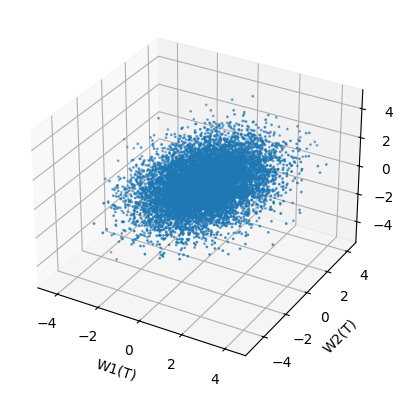

In [16]:
# Visualisation : 

WT = simulate_WT(N, T, rho)

fig = plt.figure()
ax=fig.add_subplot(projection='3d')

ax.scatter(WT[0], WT[1], WT[2], s=1)

ax.set_xlabel('W1(T)')
ax.set_ylabel('W2(T)')
ax.set_zlabel('W3(T)')

QUESTION 3 - SUITE

On estime par Monte-Carlo classique (i.e. LGN) $$ P^1 := e^{-rT} \mathbf{E} \left[ \max_i S_T^i \right] - K e^{-rT} $$
où $$  S^i_t = \exp\left(\log( S^i_t)\right) = s^i_0\exp\left(\left(r - \dfrac{\sigma_i^2}{2}\right)t + \sigma_i W^i_t\right) \quad p.s. $$

In [19]:
# mcc pour monte carlo classique
def mcc_P1(n, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K):
    
    S0_vec = np.array(S0).reshape(-1,1)
    sigma_vec = np.array(sigma).reshape(-1,1)
    
    Wt = simulate_WT(n, t, rho) # taille 3*n
    
    # Calcul de S(T) (matrice 3*n)
    # sigma_vec * Wt : calcule produit terme à terme. Mais les termes de W_t sont des lignes, qui simule W_i. 
    # et le + fait aussi la somme terme à terme. 
    
    ST = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt) # taille 3*n
    
    # On prend le max pour chaque colonne (axis=0)
    max_ST = np.max(ST, axis=0) # taille 3*n
    
    # Prix estimé
    return np.exp(-r * t) * (np.mean(max_ST) - K)

mcc_P1(10000000)

np.float64(0.30060373395997303)

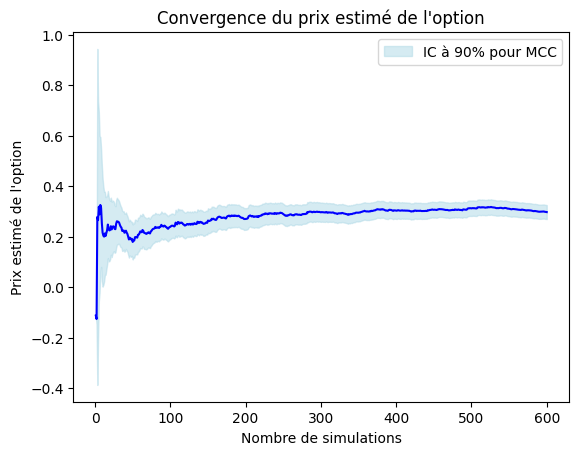

In [136]:
def visualise_mcc_P1 (Nmax, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K) :

    S0_vec = np.array(S0).reshape(-1,1)
    sigma_vec = np.array(sigma).reshape(-1,1)
    
    Wt = simulate_WT(Nmax, t, rho) 
    
    St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt) 
    
    # On prend le max pour chaque colonne (axis=0)
    max_St = np.max(St, axis=0) 

    V = max_St

    moyennes = np.cumsum(V) / np.arange(1, Nmax +1)
    moyennes_carrees = np.cumsum(V**2) / np.arange(1, Nmax +1)

    # variances[n] = variance empirique débiaisée de l'échantillon (V1, ..., V_n), divisé par n. (cf. QUESTION 5) :
    variances =  ((moyennes_carrees - moyennes**2) / np.maximum(1, np.arange(1, Nmax +1) -1))

    # intervalles de confiance à 90% :
    ica_inf = np.exp(-r * t) * (moyennes - 1.645 * np.sqrt(variances) - K)
    ica_sup = np.exp(-r * t) * (moyennes + 1.645 * np.sqrt(variances) - K)

    prix_estimes = np.exp(-r * t) * (moyennes - K)
    
    plt.plot(np.arange(1, Nmax +1), prix_estimes, color='blue')
    plt.fill_between(np.arange(1, Nmax +1), ica_inf, ica_sup, color='lightblue', alpha=0.5, label='IC à 90% pour MCC')
    plt.legend()
    plt.xlabel('Nombre de simulations')
    plt.ylabel('Prix estimé de l\'option')
    plt.title('Convergence du prix estimé de l\'option')
    

visualise_mcc_P1(600)
# =0.3

QUESTION 4 : 

In [63]:
# mca pour monte carlo antithétique

def mca_P1(n, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K):
    
    S0_vec = np.array(S0).reshape(-1,1)
    sigma_vec = np.array(sigma).reshape(-1,1)

    Wt = simulate_WT(n, t, rho)
    
    # Calcul de "max S(Wt)" 
    St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt)
    max_St = np.max(St, axis=0) 
    
    # Calcul de "max S(-Wt), pur le même Wt... "
    St_antithetic = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * (-Wt))
    max_St_antithetic = np.max(St_antithetic, axis=0)

    V = 0.5 * (max_St + max_St_antithetic)
    
    return np.exp(-r * t) * (np.mean(V) - K)

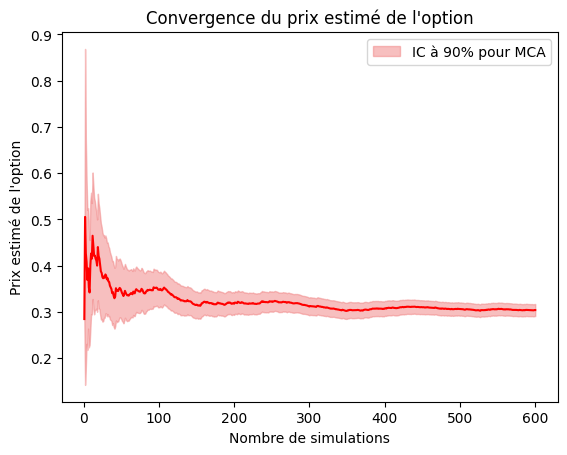

In [137]:
def visualise_mca_P1(Nmax, t=T, rho=rho, sigma=sigma, S0=S0, r=r, K=K) :
    S0_vec = np.array(S0).reshape(-1,1)
    sigma_vec = np.array(sigma).reshape(-1,1)
    
    Wt = simulate_WT(Nmax, t, rho) 

    # Calcul de "max S(Wt)" 
    St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * Wt)
    max_St = np.max(St, axis=0) 
    
    # Calcul de "max S(-Wt), pur le même Wt... "
    St_antithetic = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * t + sigma_vec * (-Wt))
    max_St_antithetic = np.max(St_antithetic, axis=0)

    V = 0.5 * (max_St + max_St_antithetic)

    moyennes = np.cumsum(V) / np.arange(1, Nmax +1)
    moyennes_carrees = np.cumsum(V**2) / np.arange(1, Nmax +1)

    # variances[n] = variance empirique débiaisée de l'échantillon (V1, ..., V_n), divisé par n. (cf. QUESTION 5) :
    variances =  ((moyennes_carrees - moyennes**2) / np.maximum(1, np.arange(1, Nmax +1) -1))

    # intervalles de confiance à 90% :
    ica_inf = np.exp(-r * t) * (moyennes - 1.645 * np.sqrt(variances) - K)
    ica_sup = np.exp(-r * t) * (moyennes + 1.645 * np.sqrt(variances) - K)

    prix_estimes = np.exp(-r * t) * (moyennes - K)

    
    plt.plot(np.arange(1, Nmax +1), prix_estimes, color='red')
    plt.fill_between(np.arange(1, Nmax +1), ica_inf, ica_sup, color='lightcoral', alpha=0.5, label='IC à 90% pour MCA')
    plt.legend()
    plt.xlabel('Nombre de simulations')
    plt.ylabel('Prix estimé de l\'option')
    plt.title('Convergence du prix estimé de l\'option')

visualise_mca_P1(600)
    

QUESTION 5 :

Pour mcc et mca, c'est le même principe. Notons $V = \max_i S_T^i $ (pour le cas mcc), ou $V =  0.5 \times [\max_i S_T^i(W_T) + \max_i S_T^i (-W_T) ]$. 

Pour déterminier les ICA : 

TCL + Slutzky : 

$$ \sqrt{n}/{\hat{s_n}} \left( \delta_n - \mathbf{E}(\max_i S_T^i) \right)  \to N(0, 1) $$

où $$ \delta_n = \dfrac{1}{n} \sum_{i=1}^n V_i $$ avec $V_i$ obserations de $V$ ; $\hat{s_n}^2$ variance empirique débiaisé de l'échantillon $(V_1, \ldots, V_n)$.

D'où l'ICA à $90\%$ suivant : 

$$ [\delta_n \pm q_{0.95} \hat{s_n} / \sqrt{n}] \, . $$

Notons que $$ \hat{s_n}^2 = \text{Var empirique débiaisé} (V_1, \ldots, V_n) = \dfrac{n}{n-1} \left( \text{moyenne}(V_i^2) - \text{moyenne} (V_i) ^2 \right) \, .$$

Dès lors, 

$$ \hat{s_n}^2 / n = \dfrac{1}{n-1} \left( \text{moyenne}(V_i^2) - \text{moyenne} (V_i) ^2 \right) \, .$$

Note : déterminer l'ICA seulement pour $\delta_n$ permet facilement de trouver l'ICA sur $ e^{-rT} (\delta_n - K) $ : suffit de faire $-K$ puis $\times e^{-rT}$ aux bornes.

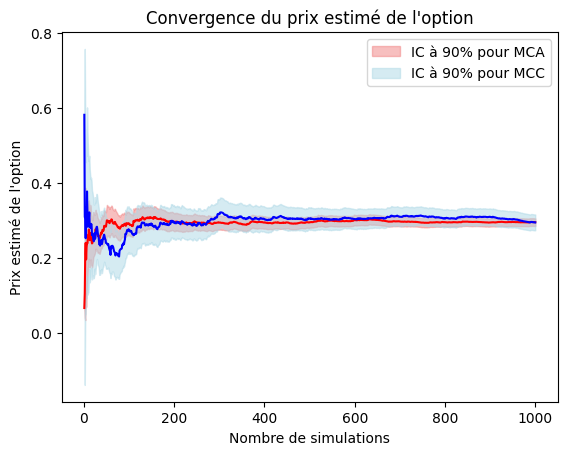

In [156]:
visualise_mca_P1(1000)
visualise_mcc_P1(1000)

QUESTION 6 : 

L'IC asymptotique va se resserrer au fur et à mesure que n grandit, les bornes convergant vers $\mathbf{E}(\max_i S_t^i))$. Choisissons donc un critère sur la largeur de l'ICA. Nous pouvons nous fixer par exemple une erreur à $1 \%$ du strike $K$. On applique ce critère seulement sur l'ICA de MCA (qui a une largeur se resserant plus vite...)

Théoriquement, nous savons que la largeur de l'Intervalle de confiance vaut : 
$$ L_n := e^{-rT} \times 2 \times q_{0.95} \, s / \sqrt{n} \, .$$

Nous voulons $ L_n < 0.01 K $, ce qui équivaut à 
$$ e^{-2 r T} \left( \dfrac{2 \times q_{0.95} \,  s}{0.01 K} \right) ^2 < n $$

Nous choisirons donc $n = \text{partie entière} \, \left( e^{-2rT} \left( \dfrac{2 \times q_{0.95} \,  \hat{s_N}}{0.01 K} \right) ^2 \right) $

pour un $N$ très grand.

In [ ]:

N = 1000000

S0_vec = np.array(S0).reshape(-1,1)
sigma_vec = np.array(sigma).reshape(-1,1)
    
Wt = simulate_WT(N, T, rho) 

# Calcul de "max S(Wt)" 
St = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * T + sigma_vec * Wt)
max_St = np.max(St, axis=0) 
    
# Calcul de "max S(-Wt), pur le même Wt... "
St_antithetic = S0_vec * np.exp((r - 0.5 * sigma_vec**2) * T + sigma_vec * (-Wt))
max_St_antithetic = np.max(St_antithetic, axis=0)

V = 0.5 * (max_St + max_St_antithetic)

moyennes = np.cumsum(V) / np.arange(1, N +1)

# écart type empirique débiaisé pour N grand
sdN = np.std(V, ddof=1) # ddof = 1 pour avoir un débiaisé.

goodN = round( np.exp(- 2 * r * T) * (2 * 1.645 * sdN / (0.01 * K))**2  )

print(goodN)



# goodN = 4200 est très bien !! 



4161


Text(0.5, 1.0, "Prix estimé de l'option par MCA en fonction de rho")

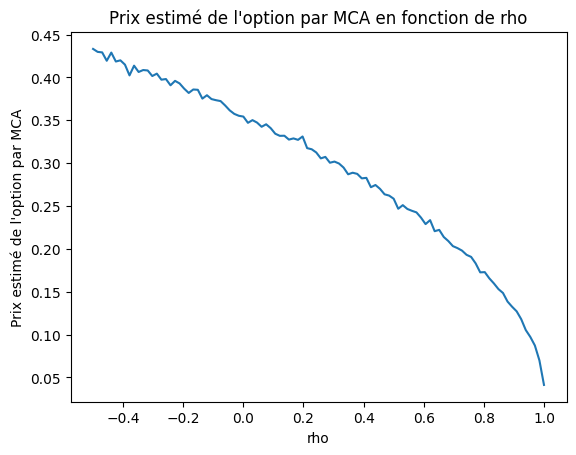

In [192]:
# Tracés estimateurs MCA de P1 pour différents rho. 

goodN = 4200

rhos = np.linspace(-0.499, 0.999, 100)
mca_P1_rhos = np.zeros(len(rhos))

for i in range(len(rhos)) : 
    mca_P1_rhos[i] = mca_P1(goodN, t=T, rho=rhos[i])

plt.plot(rhos, mca_P1_rhos)
plt.xlabel('rho')
plt.ylabel('Prix estimé de l\'option par MCA')
plt.title('Prix estimé de l\'option par MCA en fonction de rho')


Plus les actifs sont corrélés, moins l'option est chère. 